# Advanced Usage

## Setup

In [1]:
from tranpy.datasets import load_newengland
import numpy as np

X_train, X_test, y_train, y_test = load_newengland(
    test_size=0.2,
    random_state=42
)

/Users/mahmouddraz/code/tranpy/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mahmouddraz/code/tranpy/.venv/lib/python3.13/site-packages/dalex/_global_checks.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Hyperparameter Tuning

In [2]:
from tranpy.models import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20]
}

base_model = RandomForestClassifier()
grid_search = GridSearchCV(
    base_model.model_,
    param_grid,
    cv=3,
    n_jobs=-1
)

grid_search.fit(X_train[:1000], y_train[:1000])

print(f"Best params: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_:.3f}")

/Users/mahmouddraz/.local/share/uv/python/cpython-3.13.6-macos-aarch64-none/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/mahmouddraz/.local/share/uv/python/cpython-3.13.6-macos-aarch64-none/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/mahmouddraz/.local/share/uv/python/cpython-3.13.6-macos-aarch64-none/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pyp

Best params: {'max_depth': 20, 'n_estimators': 200}
Best score: 0.968


## Cross-Validation

In [3]:
from tranpy.models import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

model = DecisionTreeClassifier(max_depth=10)

scores = cross_val_score(
    model.model_,
    X_train[:1000],
    y_train[:1000],
    cv=5
)

print(f"CV Scores: {scores}")
print(f"Mean: {scores.mean():.3f} (+/- {scores.std() * 2:.3f})")

CV Scores: [0.95  0.935 0.945 0.945 0.95 ]
Mean: 0.945 (+/- 0.011)


## Feature Importance

In [4]:
from tranpy.models import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=10)
model.fit(X_train, y_train)

importances = model.model_.feature_importances_
indices = np.argsort(importances)[::-1][:10]

print("Top 10 features:")
for i, idx in enumerate(indices, 1):
    print(f"{i:2d}. Feature {idx:2d}: {importances[idx]:.4f}")

Top 10 features:
 1. Feature 17: 0.0513
 2. Feature 27: 0.0363
 3. Feature 20: 0.0343
 4. Feature 25: 0.0310
 5. Feature 16: 0.0270
 6. Feature  3: 0.0257
 7. Feature 26: 0.0247
 8. Feature 49: 0.0232
 9. Feature 19: 0.0226
10. Feature 24: 0.0224


## Ensemble Methods

In [5]:
from tranpy.models import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

models = [
    RandomForestClassifier(n_estimators=50),
    AdaBoostClassifier(n_estimators=50),
    GradientBoostingClassifier(n_estimators=50)
]

predictions = []
for model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions.append(pred)

predictions = np.array(predictions)
ensemble_pred = np.apply_along_axis(
    lambda x: np.bincount(x).argmax(),
    axis=0,
    arr=predictions
)

accuracy = (ensemble_pred == y_test).mean()
print(f"Ensemble Accuracy: {accuracy:.3f}")

Ensemble Accuracy: 0.982


## Probability Calibration

In [6]:
from tranpy.models import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV

base_model = RandomForestClassifier(n_estimators=50)
base_model.fit(X_train, y_train)

calibrated = CalibratedClassifierCV(base_model.model_, method='sigmoid', cv=3)
calibrated.fit(X_train[:1000], y_train[:1000])

proba = calibrated.predict_proba(X_test[:5])
print(f"Calibrated probabilities:\n{proba}")

Calibrated probabilities:
[[0.79781125 0.20218875]
 [0.69055217 0.30944783]
 [0.02175533 0.97824467]
 [0.02002767 0.97997233]
 [0.95173729 0.04826271]]


## Learning Curves

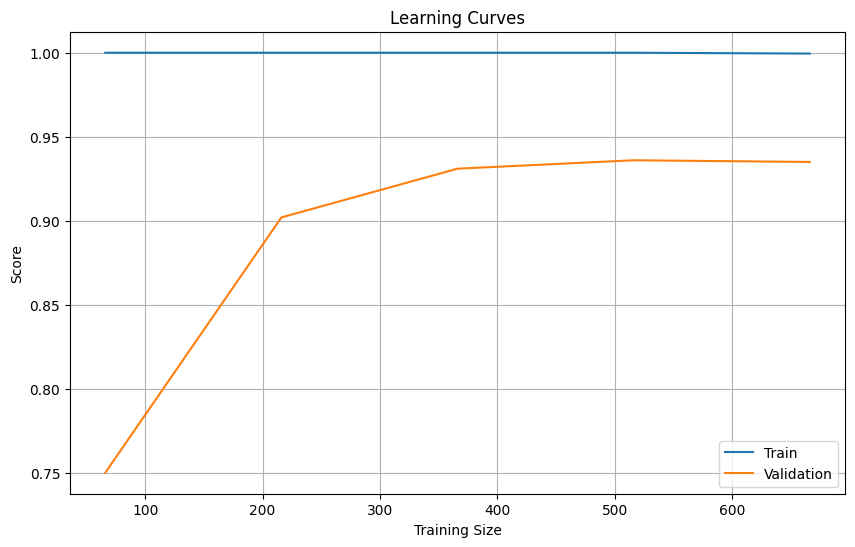

In [7]:
from tranpy.models import DecisionTreeClassifier
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

model = DecisionTreeClassifier(max_depth=10)

train_sizes, train_scores, val_scores = learning_curve(
    model.model_,
    X_train[:1000],
    y_train[:1000],
    cv=3,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation')
plt.xlabel('Training Size')
plt.ylabel('Score')
plt.title('Learning Curves')
plt.legend()
plt.grid(True)
plt.show()

## Model Persistence

In [8]:
from tranpy.models import RandomForestClassifier, save_model, load_model
import pickle

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

save_model(model, 'rf_model.pkl')

loaded_model = load_model('rf_model.pkl')
accuracy = (loaded_model.predict(X_test) == y_test).mean()

print(f"Loaded model accuracy: {accuracy:.3f}")

✓ Model saved to: rf_model.pkl
✓ Model loaded from: rf_model.pkl
Loaded model accuracy: 0.991
